# Đồ án 3: Xích Markov
## Bài toán 1

# Thông tin nhóm

| | Họ và tên | MSSV | Lớp |
|:---:|:---:|:---:|:---:|
| Thành viên 1 | Trần Kim Hữu | 24120059 | 24TNT1TN |
| Thành viên 2 | Nguyễn Danh Phương | 24120504 | 24TNT1TN |

## Câu a:

Gọi $S_n$ là tổng kết quả sau $n$ lần tung xúc xắc. Ta cần khảo sát phần dư của $S_n$ khi chia cho 7, nên chọn biến trạng thái:

$$
X_n = S_n \bmod 7
$$

Không gian trạng thái:

$$
\mathcal{S} = \{0,1,2,3,4,5,6\}
$$

Với kết quả tung xúc xắc tiếp theo là $D_{n+1} \in \{1,2,3,4,5,6\}$, ta có:

$$
X_{n+1} = (X_n + D_{n+1}) \bmod 7
$$

Do đó trạng thái ở bước tiếp theo chỉ phụ thuộc vào trạng thái hiện tại và kết quả của lần tung tiếp theo, nên đây là một xích Markov.

Ma trận chuyển $P$ có công thức tổng quát:

$$
P_{ij}=\begin{cases}
\frac{1}{6}, & \text{nếu } i-j \equiv 1,2,3,4,5,6 \pmod 7,\\
0, & \text{nếu } i=j.
\end{cases}
$$

Vì xúc xắc chỉ nhận các giá trị từ 1 đến 6, từ mỗi trạng thái có thể đi đến 6 trạng thái còn lại và không thể đứng yên.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

get_ipython().run_line_magic("matplotlib", "inline")

TOL = 1e-12

In [44]:
def assert_column_stochastic(P, tol=TOL):
    """
    Kiểm tra ma trận chuyển trạng thái theo quy ước cột.

    Args:
        P: Ma trận chuyển trạng thái cần kiểm tra.
        tol: Ngưỡng sai số khi kiểm tra phần tử âm và tổng cột.

    Returns:
        bool: True nếu P là ma trận xác suất hợp lệ.
    """
    P = np.asarray(P, dtype=float)

    if P.ndim != 2 or P.shape[0] != P.shape[1]:
        raise ValueError("P phải là ma trận vuông.")

    if np.any(P < -tol):
        raise ValueError("P có phần tử âm, không phải ma trận xác suất hợp lệ.")

    column_sums = P.sum(axis=0)
    if not np.allclose(column_sums, np.ones(P.shape[1]), atol=tol):
        raise ValueError("Tổng mỗi cột của P phải bằng 1.")

    return True


def build_transition_matrix_dice_mod7():
    """
    Xây dựng ma trận chuyển trạng thái cho X_n = S_n mod 7 khi tung xúc xắc.

    Returns:
        np.ndarray: Ma trận chuyển P kích thước 7x7.
    """
    modulus = 7
    P = np.zeros((modulus, modulus), dtype=float)

    for current_state in range(modulus):
        for dice_value in range(1, 7):
            next_state = (current_state + dice_value) % modulus
            P[next_state, current_state] += 1.0 / 6.0

    assert_column_stochastic(P)
    return P


def initial_distribution_mod7():
    """
    Tạo phân phối ban đầu của X_0 = S_0 mod 7.

    Returns:
        np.ndarray: Vector phân phối ban đầu, có xác suất 1 tại trạng thái 0.
    """
    pi0 = np.zeros(7, dtype=float)
    pi0[0] = 1.0
    return pi0

In [45]:
P = build_transition_matrix_dice_mod7()
pi0 = initial_distribution_mod7()

P_df = pd.DataFrame(
    P,
    index=[f"next={i}" for i in range(7)],
    columns=[f"current={j}" for j in range(7)]
)

pi0_df = pd.DataFrame(
    pi0,
    index=[f"X_0={i}" for i in range(7)],
    columns=["Pr"]
)

print("Ma trận chuyển trạng thái P:")
display(P_df)

print("Tổng từng cột của P:")
display(pd.DataFrame(P.sum(axis=0), index=[f"column {j}" for j in range(7)], columns=["sum"]))

print("Vector phân phối đầu pi0:")
display(pi0_df)

Ma trận chuyển trạng thái P:


,current=0,current=1,current=2,current=3,current=4,current=5,current=6
next=0,0.000000,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
next=1,0.166667,0.000000,0.166667,0.166667,0.166667,0.166667,0.166667
next=2,0.166667,0.166667,0.000000,0.166667,0.166667,0.166667,0.166667
next=3,0.166667,0.166667,0.166667,0.000000,0.166667,0.166667,0.166667
next=4,0.166667,0.166667,0.166667,0.166667,0.000000,0.166667,0.166667
next=5,0.166667,0.166667,0.166667,0.166667,0.166667,0.000000,0.166667
next=6,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.000000


Tổng từng cột của P:


,sum
column 0,1.0
column 1,1.0
column 2,1.0
column 3,1.0
column 4,1.0
column 5,1.0
column 6,1.0


Vector phân phối đầu pi0:


,Pr
X_0=0,1.0
X_0=1,0.0
X_0=2,0.0
X_0=3,0.0
X_0=4,0.0
X_0=5,0.0
X_0=6,0.0


## Câu b:

Sử dụng công thức truy hồi:

$$
\pi_n = P\pi_{n-1}
$$

In [46]:
def distribution_table(P, pi0, max_n=10):
    """
    Tính bảng phân phối của X_n = S_n mod 7 từ n=1 đến max_n.

    Args:
        P: Ma trận chuyển trạng thái.
        pi0: Vector phân phối ban đầu.
        max_n (int): Số bước tối đa cần tính.

    Returns:
        pd.DataFrame: Bảng xác suất Pr[S_n mod 7 = r] với r=0,...,6.
    """
    assert_column_stochastic(P)

    pi = np.asarray(pi0, dtype=float).copy()
    records = []

    for n in range(1, max_n + 1):
        pi = P @ pi
        records.append([n] + list(pi))

    columns = ["n"] + [f"S_n mod 7 = {r}" for r in range(7)]
    return pd.DataFrame(records, columns=columns)


table_1b = distribution_table(P, pi0, max_n=10)

print("Bảng phân phối xác suất của S_n mod 7:")
display(table_1b.round(6).set_index("n"))

Bảng phân phối xác suất của S_n mod 7:


,S_n mod 7 = 0,S_n mod 7 = 1,S_n mod 7 = 2,S_n mod 7 = 3,S_n mod 7 = 4,S_n mod 7 = 5,S_n mod 7 = 6
n,,,,,,,
1,0.000000,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2,0.166667,0.138889,0.138889,0.138889,0.138889,0.138889,0.138889
3,0.138889,0.143519,0.143519,0.143519,0.143519,0.143519,0.143519
4,0.143519,0.142747,0.142747,0.142747,0.142747,0.142747,0.142747
5,0.142747,0.142876,0.142876,0.142876,0.142876,0.142876,0.142876
6,0.142876,0.142854,0.142854,0.142854,0.142854,0.142854,0.142854
7,0.142854,0.142858,0.142858,0.142858,0.142858,0.142858,0.142858
8,0.142858,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857
9,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857


## Câu c:

Phân phối dừng $\pi$ thỏa mãn:

$$
P\pi = \pi
$$

hay:

$$
(P-I)\pi = 0
$$

kèm điều kiện chuẩn hóa:

$$
\sum_i \pi_i = 1
$$

Hệ tuyến tính được giải bằng khử Gauss với chọn phần tử trụ lớn nhất theo cột. Ta thay một phương trình trong $(P-I)\pi=0$ bằng điều kiện $\sum_i\pi_i=1$.

Để kiểm tra tính chính quy, ta xét $P^2$. Sau hai lần tung, từ một trạng thái bất kỳ có thể đi đến mọi trạng thái khác với xác suất dương, vì với mọi phần dư modulo 7 đều tồn tại ít nhất một cặp kết quả xúc xắc trong $\{1,2,3,4,5,6\}^2$ cho tổng tương ứng. Do đó $P^2>0$, nên xích Markov là chính quy. Vì vậy phân phối giới hạn tồn tại và bằng phân phối dừng.

Xích có phân phối dừng là:

$$
\pi = \left(\frac17,\frac17,\ldots,\frac17\right)^T.
$$

Tuy nhiên, với phân phối đầu $\pi_0=(1,0,\ldots,0)^T$, không tồn tại thời điểm hữu hạn $t$ sao cho $\pi_t$ đúng bằng phân phối dừng. Lý do: sau $t$ lần tung, mỗi xác suất có dạng $\frac{k}{6^t}$, trong khi $\frac17$ không thể viết dưới dạng đó vì $7 \nmid 6^t$.

Do đó, ta tìm $t$ đầu tiên sao cho $\|\pi_t-\pi\|_\infty \le \varepsilon$.

In [47]:
def solve_linear_system_gauss(A, b, tol=TOL):
    """
    Giải hệ tuyến tính Ax = b bằng khử Gauss với chọn trụ lớn nhất theo cột.

    Args:
        A: Ma trận hệ số vuông.
        b: Vector vế phải.
        tol (float): Ngưỡng xác định phần tử trụ gần bằng 0.

    Returns:
        np.ndarray: Vector nghiệm x của hệ Ax = b.
    """
    A = np.asarray(A, dtype=float).copy()
    b = np.asarray(b, dtype=float).copy()

    n = A.shape[0]
    if A.shape != (n, n) or b.shape[0] != n:
        raise ValueError("Kích thước A và b không phù hợp.")

    # Khử Gauss với chọn trụ lớn nhất theo cột
    for col in range(n):
        pivot_row = col + np.argmax(np.abs(A[col:, col]))

        if abs(A[pivot_row, col]) < tol:
            raise ValueError("Hệ tuyến tính suy biến.")

        if pivot_row != col:
            A[[col, pivot_row]] = A[[pivot_row, col]]
            b[[col, pivot_row]] = b[[pivot_row, col]]

        for row in range(col + 1, n):
            factor = A[row, col] / A[col, col]
            A[row, col:] -= factor * A[col, col:]
            b[row] -= factor * b[col]

    # Thế ngược để tìm nghiệm
    x = np.zeros(n, dtype=float)
    for row in range(n - 1, -1, -1):
        right_value = b[row] - np.dot(A[row, row + 1:], x[row + 1:])
        x[row] = right_value / A[row, row]

    return x


def stationary_distribution(P, tol=TOL):
    """
    Tìm một phân phối dừng pi của ma trận chuyển P.

    Args:
        P=: Ma trận chuyển trạng thái.
        tol (float): Ngưỡng sai số khi giải hệ và làm sạch nghiệm.

    Returns:
        tuple[bool, np.ndarray]: Cờ cho biết phân phối hợp lệ và vector phân phối dừng.
    """
    assert_column_stochastic(P)
    n = P.shape[0]

    A = P - np.eye(n)
    b = np.zeros(n)

    # Thay phương trình cuối bằng điều kiện tổng xác suất bằng 1
    A[-1, :] = np.ones(n)
    b[-1] = 1.0

    pi = solve_linear_system_gauss(A, b, tol)

    # Làm sạch sai số
    pi[np.abs(pi) < tol] = 0.0

    if abs(pi.sum()) > tol:
        pi = pi / pi.sum()

    exists = (
        np.all(pi >= -TOL)
        and np.allclose(pi.sum(), 1.0, atol=TOL)
        and np.allclose(P @ pi, pi, atol=TOL)
    )

    return exists, pi


def is_regular_markov_chain(P, max_power=50, tol=TOL):
    """
    Kiểm tra tính chính quy của chuỗi Markov với ma trận chuyển P.

    Args:
        P (array-like): Ma trận chuyển trạng thái.
        max_power (int): Số mũ tối đa của P được kiểm tra.
        tol (float): Ngưỡng để xem một phần tử là dương.

    Returns:
        tuple[bool, int | None]: Cờ chính quy và số mũ k đầu tiên làm P^k dương hoàn toàn.
    """
    assert_column_stochastic(P)
    n = P.shape[0]
    power = np.eye(n)

    for k in range(1, max_power + 1):
        power = P @ power
        if np.all(power > tol):
            return True, k

    return False, None


def find_convergence_time(P, pi0, stationary, eps=TOL, max_t=10000):
    """
    Tìm thời điểm đầu tiên pi_t hội tụ gần phân phối dừng theo chuẩn vô cùng.

    Args:
        P: Ma trận chuyển trạng thái.
        pi0: Vector phân phối ban đầu.
        stationary: Vector phân phối dừng dùng làm mốc so sánh.
        eps (float): Ngưỡng sai số hội tụ theo chuẩn vô cùng.
        max_t (int): Thời điểm tối đa được kiểm tra.

    Returns:
        tuple[int | None, np.ndarray, float]: Thời điểm hội tụ, phân phối cuối cùng được tính và sai số chuẩn vô cùng.
    """
    assert_column_stochastic(P)

    pi = np.asarray(pi0, dtype=float).copy()

    for t in range(max_t + 1):
        error = np.max(np.abs(pi - stationary))
        if error <= eps:
            return t, pi, error

        pi = P @ pi

    return None, pi, np.max(np.abs(pi - stationary))

In [48]:
exists, pi_stationary = stationary_distribution(P)

if exists:
    print("Xích tìm được phân phối dừng hợp lệ.")

    stationary_df = pd.DataFrame(
        pi_stationary,
        index=[f"state={i}" for i in range(7)],
        columns=["Phân phối dừng"]
    )

    print("Phân phối dừng:")
    display(stationary_df.round(15))

    regular, regular_power = is_regular_markov_chain(P)

    if regular:
        print("Xích là chính quy, có nghĩa là tồn tại một số mũ k sao cho P^k dương toàn bộ.")
        print("Số mũ k đầu tiên để P^k dương toàn bộ:", regular_power)
    else:
        print("Chưa tìm thấy k để P^k dương toàn bộ trong giới hạn kiểm tra.")

    t_conv, pi_t, error = find_convergence_time(P, pi0, pi_stationary, eps=TOL, max_t=10000)

    if t_conv is not None:
        print("Không tồn tại thời điểm hữu hạn t để pi_t đúng bằng phân phối dừng khi xuất phát từ X_0 = 0.")
        print(f"Nếu dùng tiêu chuẩn xấp xỉ eps = {TOL}, thời điểm t đầu tiên là: t = {t_conv}")
        print(f"Sai số lớn nhất tại thời điểm đó: {error:.3e}")

        pi_t_df = pd.DataFrame(
            pi_t,
            index=[f"state={i}" for i in range(7)],
            columns=[f"pi_{t_conv}"]
        )

        display(pi_t_df.round(15))
    else:
        print("Không tìm thấy thời điểm hội tụ xấp xỉ trong giới hạn max_t.")
        print(f"Sai số lớn nhất tại thời điểm cuối cùng: {error:.3e}")
else:
    print("Xích không tìm được phân phối dừng hợp lệ.")
    print("Không thể tiếp tục kiểm tra chính quy và hội tụ vì phân phối dừng không hợp lệ.")

Xích tìm được phân phối dừng hợp lệ.
Phân phối dừng:


,Phân phối dừng
state=0,0.142857
state=1,0.142857
state=2,0.142857
state=3,0.142857
state=4,0.142857
state=5,0.142857
state=6,0.142857


Xích là chính quy, có nghĩa là tồn tại một số mũ k sao cho P^k dương toàn bộ.
Số mũ k đầu tiên để P^k dương toàn bộ: 2
Không tồn tại thời điểm hữu hạn t để pi_t đúng bằng phân phối dừng khi xuất phát từ X_0 = 0.
Nếu dùng tiêu chuẩn xấp xỉ eps = 1e-12, thời điểm t đầu tiên là: t = 16
Sai số lớn nhất tại thời điểm đó: 3.037e-13


,pi_16
state=0,0.142857
state=1,0.142857
state=2,0.142857
state=3,0.142857
state=4,0.142857
state=5,0.142857
state=6,0.142857


,t,infinity_norm_error
0,0,8.571429e-01
1,1,1.428571e-01
2,2,2.380952e-02
3,3,3.968254e-03
4,4,6.613757e-04
5,5,1.102293e-04
6,6,1.837155e-05
7,7,3.061924e-06
8,8,5.103207e-07
9,9,8.505345e-08


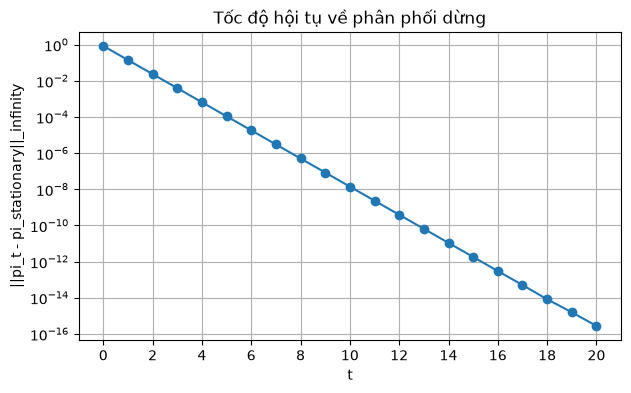

In [49]:
def convergence_error_table(P, pi0, stationary, max_t=20):
    """
    Lập bảng sai số hội tụ của pi_t so với phân phối dừng theo chuẩn vô cùng.

    Args:
        P: Ma trận chuyển trạng thái theo quy ước cột.
        pi0: Vector phân phối ban đầu.
        stationary: Vector phân phối dừng dùng làm mốc so sánh.
        max_t (int): Thời điểm tối đa được đưa vào bảng.

    Returns:
        pd.DataFrame: Bảng gồm t và infinity_norm_error từ 0 đến max_t.
    """
    pi = np.asarray(pi0, dtype=float).copy()
    records = []

    for t in range(max_t + 1):
        error = np.max(np.abs(pi - stationary))
        records.append([t, error])
        pi = P @ pi

    return pd.DataFrame(records, columns=["t", "infinity_norm_error"])


error_df = convergence_error_table(P, pi0, pi_stationary, max_t=20)
display(error_df)

plt.figure(figsize=(7, 4))
plt.plot(error_df["t"], error_df["infinity_norm_error"], marker="o")
plt.yscale("log")
plt.xlabel("t")
plt.ylabel("||pi_t - pi_stationary||_infinity")
plt.title("Tốc độ hội tụ về phân phối dừng")
plt.xticks(range(0, 21, 2))
plt.grid(True)
plt.show()

## Câu d:

Gọi:

$$
T = \min\{i \ge 1: S_i \equiv 0 \pmod 7\}
$$

Cần tính:

$$
\Pr(T \le n)
$$

Cách làm:

- Ban đầu khối xác suất còn hoạt động nằm ở trạng thái 0.
- Sau mỗi lần tung, nếu đi vào trạng thái 0 thì cộng xác suất đó vào biến `stopped_probability`.
- Nếu chưa vào 0 thì tiếp tục giữ lại để tung bước tiếp theo.

In [50]:
def probability_stop_within_n(n):
    """
    Tính xác suất quá trình dừng không quá n lần tung.

    Args:
        n (int): Số lần tung tối đa.

    Returns:
        float: Xác suất Pr(T <= n), với T là thời điểm đầu tiên sau 0 có S_T mod 7 = 0.
    """
    if n < 0:
        raise ValueError("n phải không âm.")

    modulus = 7
    active = np.zeros(modulus, dtype=float)
    active[0] = 1.0

    stopped_probability = 0.0

    for step in range(1, n + 1):
        new_active = np.zeros(modulus, dtype=float)

        for current_state in range(modulus):
            if active[current_state] == 0:
                continue

            for dice_value in range(1, 7):
                next_state = (current_state + dice_value) % modulus
                probability = active[current_state] / 6.0

                if next_state == 0:
                    stopped_probability += probability
                else:
                    new_active[next_state] += probability

        active = new_active

    return stopped_probability


def stop_probability_table(max_n=20):
    """
    Lập bảng Pr(T <= n) với n từ 1 đến max_n.

    Args:
        max_n (int): Số lần tung tối đa trong bảng.

    Returns:
        pd.DataFrame: Bảng gồm n và Pr(T <= n).
    """
    records = []
    for n in range(1, max_n + 1):
        records.append([n, probability_stop_within_n(n)])

    return pd.DataFrame(records, columns=["n", "Pr(T <= n)"])


stop_df = stop_probability_table(max_n=20)

print("Bảng xác suất dừng không quá n lần tung:")
display(stop_df.round(6).set_index("n"))

Bảng xác suất dừng không quá n lần tung:


,Pr(T <= n)
n,
1,0.000000
2,0.166667
3,0.305556
4,0.421296
5,0.517747
6,0.598122
7,0.665102
8,0.720918
9,0.767432


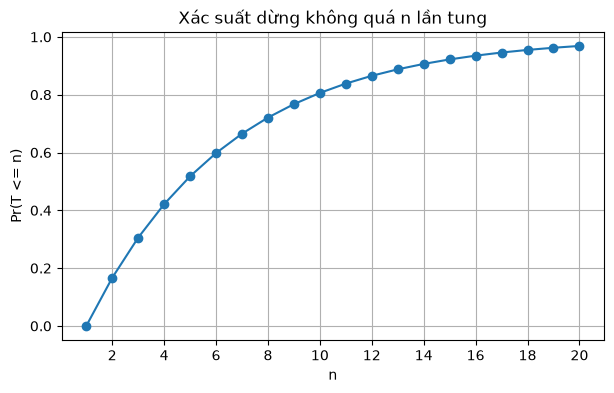

In [51]:
plt.figure(figsize=(7, 4))
plt.plot(stop_df["n"], stop_df["Pr(T <= n)"], marker="o")
plt.xlabel("n")
plt.ylabel("Pr(T <= n)")
plt.title("Xác suất dừng không quá n lần tung")
plt.xticks(range(2, 21, 2))
plt.grid(True)
plt.show()